In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sweetviz as sv

In [7]:
df = pd.read_csv("C:/Users/saura/OneDrive/Desktop/student_dropout_prediction/data/student-dropout.csv")

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully
Shape: (4000, 56)


,Student_ID,Semester,Age,Gender,Address,Region,Family_Size,Family_Income,First_Generation_Student,Parental_Status,...,Family_Relationship,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Tuition_Fee_Payment_Status,Scholarship_Available,Financial_Aid,Dropped_Out
0,STU0001,1,23,Male,Rural,East,<=3,High,Yes,Together,...,2,3,2,2,3,2,Paid,Yes,No,0
1,STU0001,2,24,Male,Rural,East,<=3,High,Yes,Together,...,2,3,5,5,5,4,Paid,Yes,No,0
2,STU0001,3,24,Male,Rural,East,<=3,High,Yes,Together,...,2,5,2,4,3,1,Partial,Yes,No,0
3,STU0001,4,25,Male,Rural,East,<=3,High,Yes,Together,...,2,4,3,5,4,1,Paid,Yes,No,0
4,STU0002,1,20,Female,Rural,West,>3,High,No,Together,...,5,5,5,5,4,1,Unpaid,Yes,No,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 56 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   4000 non-null   object 
 1   Semester                     4000 non-null   int64  
 2   Age                          4000 non-null   int64  
 3   Gender                       4000 non-null   object 
 4   Address                      4000 non-null   object 
 5   Region                       4000 non-null   object 
 6   Family_Size                  4000 non-null   object 
 7   Family_Income                4000 non-null   object 
 8   First_Generation_Student     4000 non-null   object 
 9   Parental_Status              4000 non-null   object 
 10  Mother_Education             2992 non-null   object 
 11  Father_Education             2972 non-null   object 
 12  Mother_Job                   4000 non-null   object 
 13  Father_Job        

In [9]:
df.isnull().sum().sort_values(ascending=False)

Father_Education               1028
Mother_Education               1008
Student_ID                        0
Semester                          0
Address                           0
Region                            0
Age                               0
Gender                            0
Family_Income                     0
Family_Size                       0
Parental_Status                   0
First_Generation_Student          0
Mother_Job                        0
Father_Job                        0
Reason_for_Choosing_School        0
Guardian                          0
GPA                               0
Marks_Math                        0
Marks_Physics                     0
Marks_CS                          0
Marks_English                     0
Marks_Economics                   0
Marks_Elective                    0
Grade_1                           0
Grade_2                           0
Final_Grade                       0
Number_of_Backlogs                0
Number_of_Failures          

In [10]:
df.describe()

,Semester,Age,GPA,Marks_Math,Marks_Physics,Marks_CS,Marks_English,Marks_Economics,Marks_Elective,Grade_1,...,Login_Frequency_Per_Week,Class_Engagement_Score,Travel_Time,Family_Relationship,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Dropped_Out
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,2.500000,21.898000,6.175292,46.322850,46.438175,46.319725,46.349000,46.253675,46.124425,11.090000,...,3.872250,4.93610,2.479000,3.114000,3.019000,2.243000,2.981000,3.037000,2.984500,0.132500
std,1.118174,2.697298,1.872700,16.147046,16.206036,16.314358,15.940721,16.134270,16.195135,3.677945,...,2.022363,1.87003,1.100846,1.399819,1.425359,1.157059,1.409658,1.413022,1.407748,0.339076
min,1.000000,17.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.750000,20.000000,4.870000,35.600000,35.100000,35.175000,35.375000,35.200000,35.200000,9.000000,...,2.000000,3.60000,1.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,0.000000
50%,2.500000,22.000000,6.190000,46.400000,46.500000,46.450000,46.500000,46.500000,45.950000,11.000000,...,4.000000,4.90000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,0.000000
75%,3.250000,24.000000,7.510000,57.100000,57.900000,57.600000,57.300000,57.300000,57.400000,14.000000,...,5.000000,6.20000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,0.000000
max,4.000000,27.000000,10.000000,91.900000,93.200000,99.000000,94.700000,96.800000,94.200000,20.000000,...,13.000000,10.00000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000


In [11]:
df.columns

Index(['Student_ID', 'Semester', 'Age', 'Gender', 'Address', 'Region',
       'Family_Size', 'Family_Income', 'First_Generation_Student',
       'Parental_Status', 'Mother_Education', 'Father_Education', 'Mother_Job',
       'Father_Job', 'Reason_for_Choosing_School', 'Guardian', 'GPA',
       'Marks_Math', 'Marks_Physics', 'Marks_CS', 'Marks_English',
       'Marks_Economics', 'Marks_Elective', 'Grade_1', 'Grade_2',
       'Final_Grade', 'Number_of_Backlogs', 'Number_of_Failures',
       'Attendance_Pct', 'Assignment_Score', 'Credits_Completed', 'Study_Time',
       'Number_of_Absences', 'LMS_Activity_Score', 'Login_Frequency_Per_Week',
       'Participation_Level', 'Class_Engagement_Score', 'School_Support',
       'Family_Support', 'Extra_Paid_Class', 'Extra_Curricular_Activities',
       'Wants_Higher_Education', 'Internet_Access', 'In_Relationship',
       'Attended_Nursery', 'Travel_Time', 'Family_Relationship', 'Free_Time',
       'Going_Out', 'Weekend_Alcohol_Consumption',
    

In [12]:
df["Dropped_Out"].value_counts()

Dropped_Out
0    3470
1     530
Name: count, dtype: int64

In [13]:
df["Dropped_Out"].value_counts(normalize=True) * 100

Dropped_Out
0    86.75
1    13.25
Name: proportion, dtype: float64

In [14]:
df = df.drop("Student_ID", axis=1)

print("Student_ID removed")

Student_ID removed


In [15]:
df.head()

,Semester,Age,Gender,Address,Region,Family_Size,Family_Income,First_Generation_Student,Parental_Status,Mother_Education,...,Family_Relationship,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Tuition_Fee_Payment_Status,Scholarship_Available,Financial_Aid,Dropped_Out
0,1,23,Male,Rural,East,<=3,High,Yes,Together,Primary,...,2,3,2,2,3,2,Paid,Yes,No,0
1,2,24,Male,Rural,East,<=3,High,Yes,Together,Primary,...,2,3,5,5,5,4,Paid,Yes,No,0
2,3,24,Male,Rural,East,<=3,High,Yes,Together,Primary,...,2,5,2,4,3,1,Partial,Yes,No,0
3,4,25,Male,Rural,East,<=3,High,Yes,Together,Primary,...,2,4,3,5,4,1,Paid,Yes,No,0
4,1,20,Female,Rural,West,>3,High,No,Together,Higher,...,5,5,5,5,4,1,Unpaid,Yes,No,1


In [16]:
df["Mother_Education"] = df["Mother_Education"].fillna("Unknown")

df["Father_Education"] = df["Father_Education"].fillna("Unknown")

print("Missing values handled")

Missing values handled


In [17]:
df.isnull().sum().sum()

np.int64(0)

In [18]:
df.select_dtypes(include="object").columns

Index(['Gender', 'Address', 'Region', 'Family_Size', 'Family_Income',
       'First_Generation_Student', 'Parental_Status', 'Mother_Education',
       'Father_Education', 'Mother_Job', 'Father_Job',
       'Reason_for_Choosing_School', 'Guardian', 'Participation_Level',
       'School_Support', 'Family_Support', 'Extra_Paid_Class',
       'Extra_Curricular_Activities', 'Wants_Higher_Education',
       'Internet_Access', 'In_Relationship', 'Attended_Nursery',
       'Tuition_Fee_Payment_Status', 'Scholarship_Available', 'Financial_Aid'],
      dtype='object')

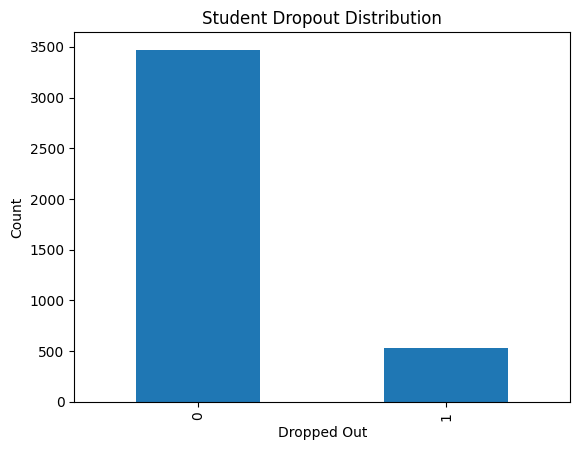

In [19]:
df["Dropped_Out"].value_counts().plot(kind="bar")

plt.title("Student Dropout Distribution")
plt.xlabel("Dropped Out")
plt.ylabel("Count")

plt.show()

In [20]:
report = sv.analyze(df)

report.show_html("student_dropout_report.html")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:02 -> (00:00 left)


Report student_dropout_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [21]:
df.to_csv("../data/cleaned_student_dropout.csv", index=False)

print("Cleaned dataset saved")

Cleaned dataset saved


In [22]:
X = df.drop("Dropped_Out", axis=1)

y = df["Dropped_Out"]

print(X.shape)
print(y.shape)

(4000, 54)
(4000,)


In [23]:
categorical_cols = X.select_dtypes(include="object").columns

print(categorical_cols)

Index(['Gender', 'Address', 'Region', 'Family_Size', 'Family_Income',
       'First_Generation_Student', 'Parental_Status', 'Mother_Education',
       'Father_Education', 'Mother_Job', 'Father_Job',
       'Reason_for_Choosing_School', 'Guardian', 'Participation_Level',
       'School_Support', 'Family_Support', 'Extra_Paid_Class',
       'Extra_Curricular_Activities', 'Wants_Higher_Education',
       'Internet_Access', 'In_Relationship', 'Attended_Nursery',
       'Tuition_Fee_Payment_Status', 'Scholarship_Available', 'Financial_Aid'],
      dtype='object')


In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print("Encoding complete")

Encoding complete


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3200, 54)
(800, 54)


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [27]:
y_pred = rf_model.predict(X_test)

In [28]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.94625

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       692
           1       0.87      0.71      0.78       108

    accuracy                           0.95       800
   macro avg       0.91      0.85      0.88       800
weighted avg       0.94      0.95      0.94       800



In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Models dictionary
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        random_state=42
    )
}

# Store results
results = []

# Train and evaluate models
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

# Create results dataframe
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

# Sort by accuracy
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

c:\Users\saura\anaconda3\envs\student_dropout\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.94625,0.865169,0.712963,0.781726
3,Gradient Boosting,0.94250,0.787037,0.787037,0.787037
1,Decision Tree,0.94125,0.756303,0.833333,0.792952
5,XGBoost,0.93875,0.765766,0.787037,0.776256
0,Logistic Regression,0.91875,0.693694,0.712963,0.703196
4,KNN,0.90000,0.662791,0.527778,0.587629


In [30]:
LogisticRegression(
    max_iter=2000,
    solver="liblinear"
)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalt

In [31]:
best_model = GradientBoostingClassifier(
    random_state=42
)

best_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
26,Number_of_Failures,0.376433
25,Number_of_Backlogs,0.225262
15,GPA,0.122178
27,Attendance_Pct,0.120101
51,Tuition_Fee_Payment_Status,0.032366
32,LMS_Activity_Score,0.022927
0,Semester,0.013016
35,Class_Engagement_Score,0.010596
19,Marks_English,0.009182
16,Marks_Math,0.007293


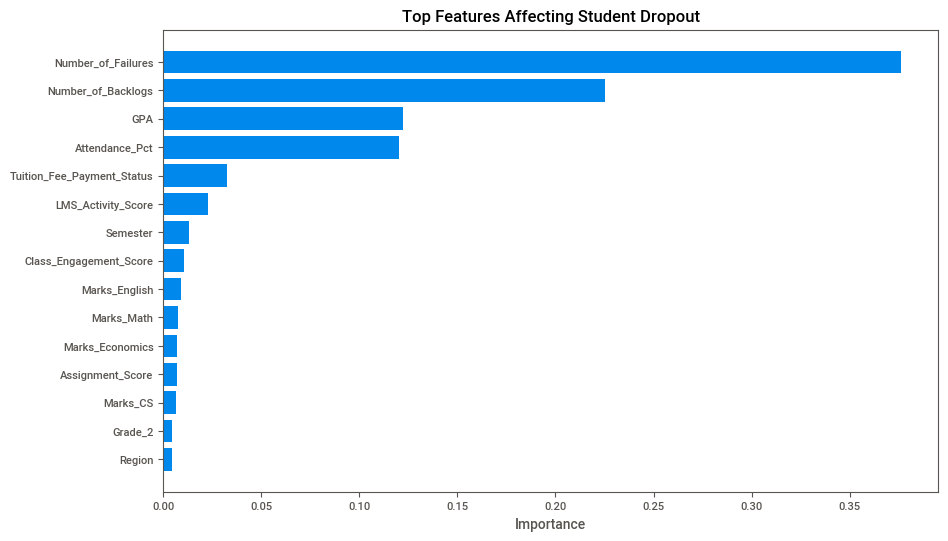

In [32]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Features Affecting Student Dropout")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [33]:
best_model = GradientBoostingClassifier(
    random_state=42
)

best_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [34]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

In [35]:
probabilities = best_model.predict_proba(X_test)

probabilities[:5]

array([[0.99779181, 0.00220819],
       [0.99779181, 0.00220819],
       [0.9979362 , 0.0020638 ],
       [0.99743776, 0.00256224],
       [0.99743776, 0.00256224]])

In [36]:
dropout_probability = probabilities[:, 1]

In [37]:
def risk_category(prob):

    if prob < 0.20:
        return "Low Risk"

    elif prob < 0.50:
        return "Medium Risk"

    else:
        return "High Risk"

In [39]:
risk_levels = [
    risk_category(prob)
    for prob in dropout_probability
]

In [40]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Dropout_Probability": dropout_probability,
    "Risk_Level": risk_levels
})

results.head(10)

,Actual,Predicted,Dropout_Probability,Risk_Level
0,0,0,0.002208,Low Risk
1,0,0,0.002208,Low Risk
2,0,0,0.002064,Low Risk
3,0,0,0.002562,Low Risk
4,0,0,0.002562,Low Risk
5,0,0,0.001989,Low Risk
6,0,0,0.653784,High Risk
7,1,1,0.918607,High Risk
8,0,0,0.002090,Low Risk
9,0,0,0.002064,Low Risk


In [41]:
y.value_counts()

Dropped_Out
0    3470
1     530
Name: count, dtype: int64

In [42]:
from sklearn.ensemble import GradientBoostingClassifier

best_model = GradientBoostingClassifier(
    random_state=42
)

best_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [43]:
import shap

explainer = shap.Explainer(
    best_model,
    X_train
)

In [44]:
shap_values = explainer(X_test)

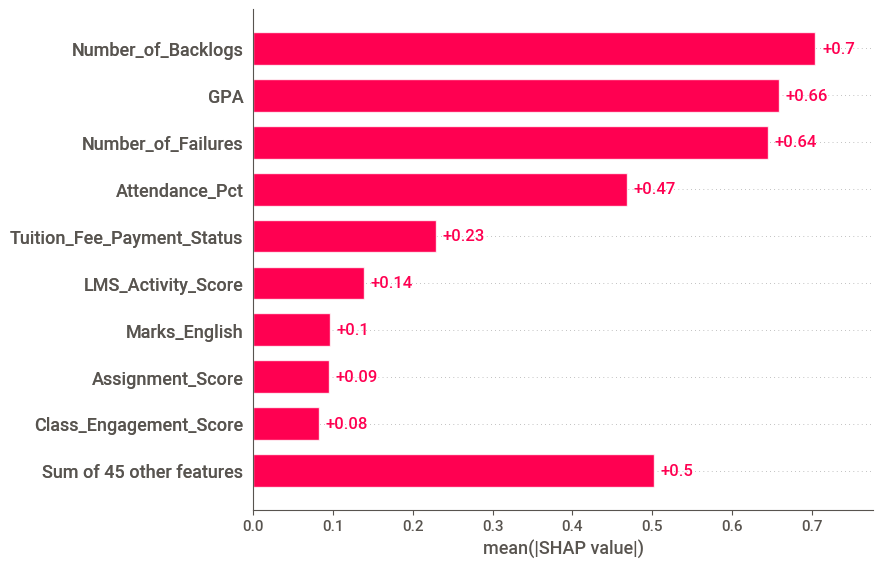

In [45]:
shap.plots.bar(shap_values)

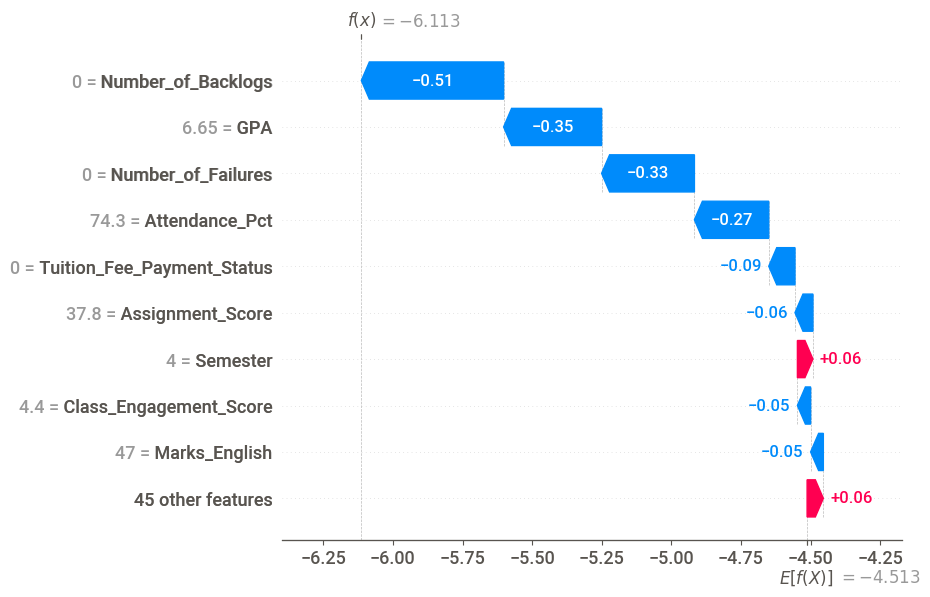

In [46]:
shap.plots.waterfall(shap_values[0])

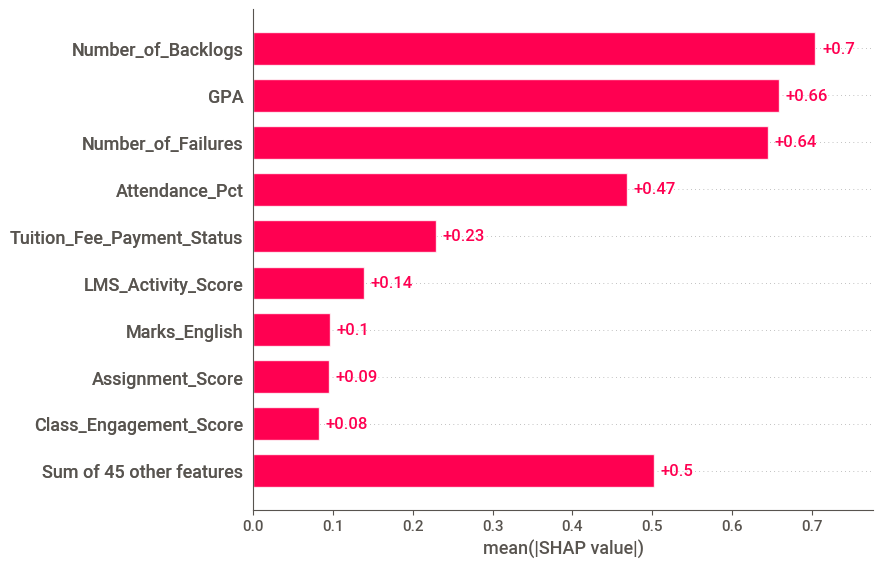

In [47]:
shap.plots.bar(shap_values)

In [48]:
def recommend_action(row):

    recommendations = []

    if row["GPA"] < 5:
        recommendations.append(
            "Academic Counseling"
        )

    if row["Attendance"] < 60:
        recommendations.append(
            "Mentorship Support"
        )

    if row["Financial_Aid"] == 0:
        recommendations.append(
            "Financial Aid Guidance"
        )

    return recommendations

In [49]:
import joblib

joblib.dump(
    best_model,
    "../models/student_dropout_model.pkl"
)

print("Model saved")

Model saved


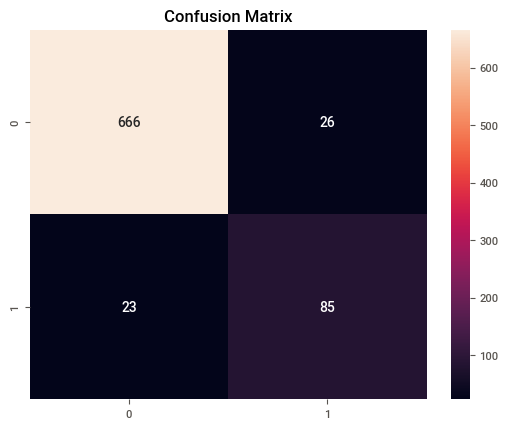

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.show()